# HW5 
panorama

In [1]:
import os
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

%matplotlib inline

IN_DIR = 'Input_Images'
OUT_DIR = 'Output_Images'
for p in ['Part_1','Part_2','Part_3','Part_4','Part_5']:
    os.makedirs(OUT_DIR+'/'+p, exist_ok=True)

pairs = sorted(os.listdir(IN_DIR))
print(pairs)

['Pair1_Courtyard', 'Pair2_Cubicle', 'Pair3_Whiteboard']


In [2]:
def load_rgb(path):
    im = cv2.imread(path)
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

data = {}
for pair_name in pairs:
    folder = IN_DIR+'/'+pair_name
    f1, f2 = sorted(os.listdir(folder))
    im1 = load_rgb(folder+'/'+f1)
    im2 = load_rgb(folder+'/'+f2)
    data[pair_name] = {'im1': im1, 'im2': im2}
    print(pair_name, im1.shape, im2.shape)

Pair1_Courtyard (792, 528, 3) (792, 528, 3)


Pair2_Cubicle (864, 1152, 3) (864, 1152, 3)
Pair3_Whiteboard (512, 384, 3) (512, 384, 3)


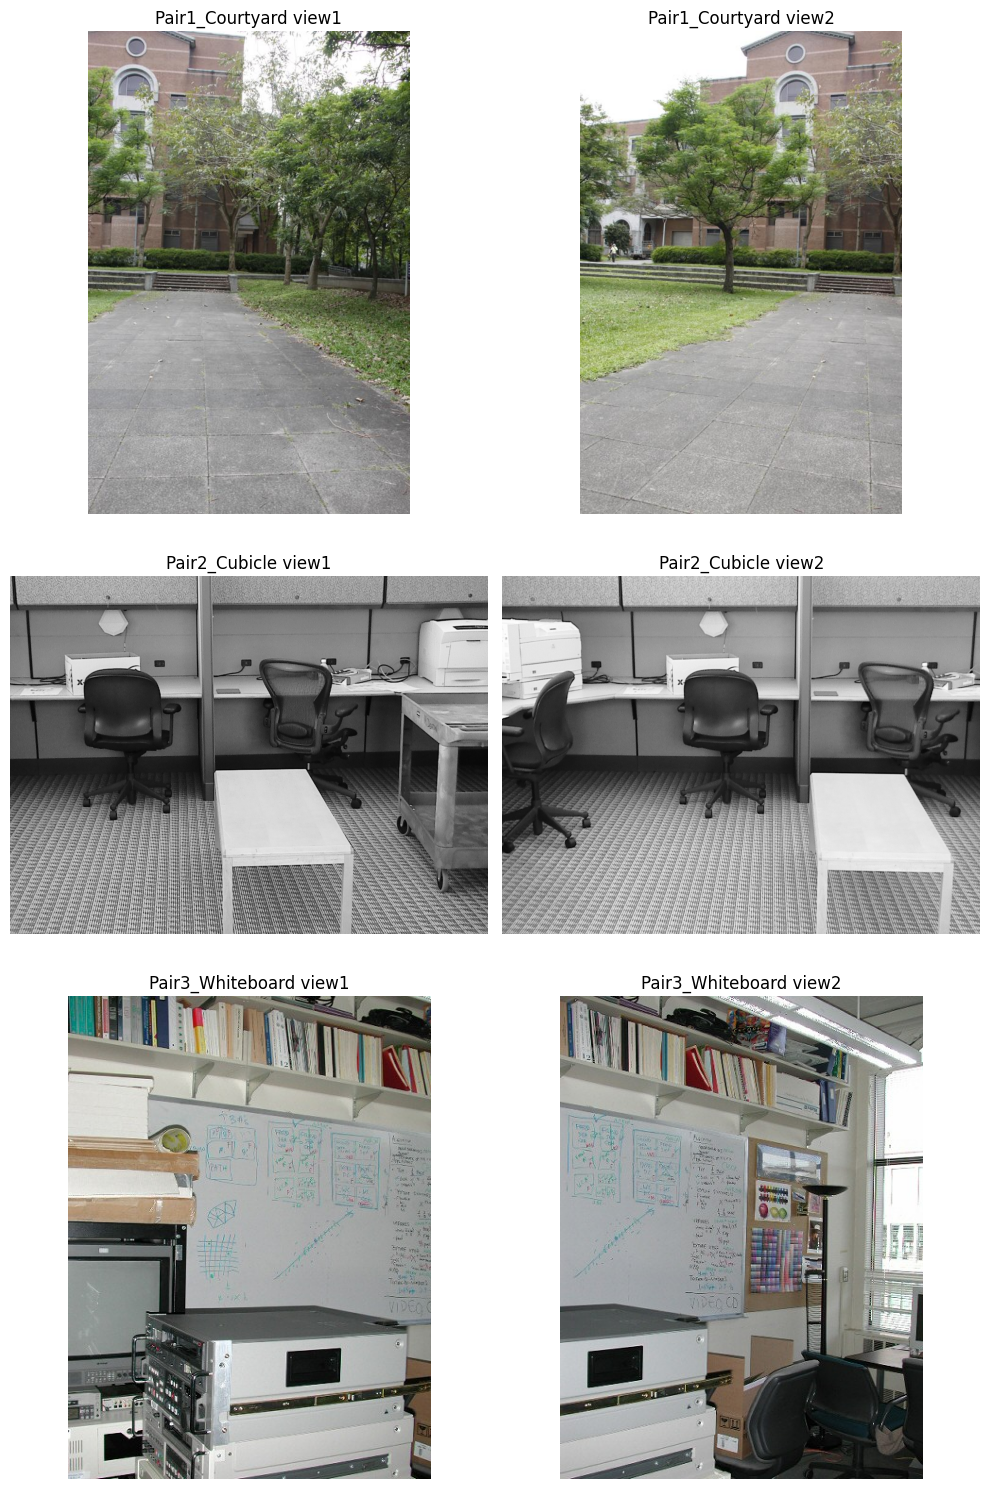

In [3]:
fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 5*len(pairs)))
for i,pair_name in enumerate(pairs):
    axes[i,0].imshow(data[pair_name]['im1']); axes[i,0].set_title(pair_name+' view1'); axes[i,0].axis('off')
    axes[i,1].imshow(data[pair_name]['im2']); axes[i,1].set_title(pair_name+' view2'); axes[i,1].axis('off')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۱ - نقاط کلیدی: Harris، FAST، SIFT
</div>

In [4]:
def to_gray(im):
    return cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)

# اول Harris رو با آستانه‌ی معمول (0.01*max) امتحان کردم، ولی هزاران نقطه به هم چسبیده برمیگردوند
# (یه لکه‌ی بزرگ به جای نقاط مجزا). با non-max suppression (فقط ماکزیمم‌های محلی) تمیزتر شد.
def harris_keypoints(gray, thresh_ratio=0.01):
    h = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
    h_dil = cv2.dilate(h, None)
    mask = (h > thresh_ratio*h.max()) & (h == h_dil)
    ys, xs = np.where(mask)
    return list(zip(xs, ys))

def fast_keypoints(gray):
    fast = cv2.FastFeatureDetector_create()
    return fast.detect(gray, None)

def sift_keypoints(gray):
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(gray, None)
    return kp, des

def draw_harris(im, pts):
    vis = im.copy()
    for x,y in pts:
        cv2.circle(vis, (int(x),int(y)), 3, (255,0,0), 1)
    return vis

In [ ]:
kp_counts = {}
sift_data = {}  

for pair_name in pairs:
    for vname in ['im1','im2']:
        im = data[pair_name][vname]
        gray = to_gray(im)

        harris_pts = harris_keypoints(gray)
        vis_h = draw_harris(im, harris_pts)
        cv2.imwrite(f'{OUT_DIR}/Part_1/{pair_name}_{vname}_harris.png', cv2.cvtColor(vis_h, cv2.COLOR_RGB2BGR))

        fast_kp = fast_keypoints(gray)
        vis_f = cv2.drawKeypoints(im, fast_kp, None, color=(0,255,0))
        cv2.imwrite(f'{OUT_DIR}/Part_1/{pair_name}_{vname}_fast.png', cv2.cvtColor(vis_f, cv2.COLOR_RGB2BGR))

        sift_kp, sift_des = sift_keypoints(gray)
        vis_s = cv2.drawKeypoints(im, sift_kp, None, color=(0,150,255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        cv2.imwrite(f'{OUT_DIR}/Part_1/{pair_name}_{vname}_sift.png', cv2.cvtColor(vis_s, cv2.COLOR_RGB2BGR))

        kp_counts[(pair_name,vname)] = {'harris':len(harris_pts), 'fast':len(fast_kp), 'sift':len(sift_kp)}
        sift_data[(pair_name,vname)] = (sift_kp, sift_des)

        print(pair_name, vname, kp_counts[(pair_name,vname)])

Pair1_Courtyard im1 {'harris': 2246, 'fast': 18048, 'sift': 3536}


Pair1_Courtyard im2 {'harris': 1300, 'fast': 15704, 'sift': 3001}


Pair2_Cubicle im1 {'harris': 14046, 'fast': 31655, 'sift': 9502}


Pair2_Cubicle im2 {'harris': 7161, 'fast': 29499, 'sift': 8726}
Pair3_Whiteboard im1 {'harris': 566, 'fast': 3963, 'sift': 739}


Pair3_Whiteboard im2 {'harris': 634, 'fast': 4949, 'sift': 839}


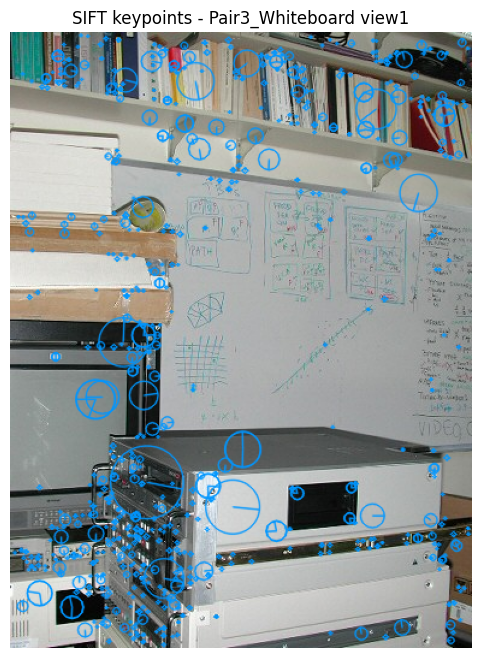

In [ ]:
plt.figure(figsize=(6,8))
plt.imshow(cv2.imread(f'{OUT_DIR}/Part_1/Pair3_Whiteboard_im1_sift.png')[:,:,::-1])
plt.axis('off')
plt.title('SIFT keypoints - Pair3_Whiteboard view1')
plt.show()


<div dir="rtl" style="text-align: right;">
 قسمت ۲ - بردار ویژگی SIFT و بهترین تطابق
</div>

In [ ]:
def best_match_pair(des1, des2):
    d1n = des1 / np.linalg.norm(des1, axis=1, keepdims=True)
    d2n = des2 / np.linalg.norm(des2, axis=1, keepdims=True)
    sim = d1n @ d2n.T   
    i, j = np.unravel_index(np.argmax(sim), sim.shape)
    return i, j, sim[i,j]

for pair_name in pairs:
    kp1, des1 = sift_data[(pair_name,'im1')]
    kp2, des2 = sift_data[(pair_name,'im2')]
    i, j, s = best_match_pair(des1, des2)
    print(pair_name, 'best match: kp1[%d] <-> kp2[%d], normalized dot product = %.4f'%(i,j,s))

    im1 = data[pair_name]['im1'].copy()
    im2 = data[pair_name]['im2'].copy()
    cv2.circle(im1, tuple(np.round(kp1[i].pt).astype(int)), 10, (255,0,0), 3)
    cv2.circle(im2, tuple(np.round(kp2[j].pt).astype(int)), 10, (255,0,0), 3)

    h = max(im1.shape[0], im2.shape[0])
    canvas = np.zeros((h, im1.shape[1]+im2.shape[1], 3), dtype=np.uint8)
    canvas[:im1.shape[0], :im1.shape[1]] = im1
    canvas[:im2.shape[0], im1.shape[1]:] = im2
    cv2.imwrite(f'{OUT_DIR}/Part_2/{pair_name}_best_match.png', cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))

Pair1_Courtyard best match: kp1[787] <-> kp2[2422], normalized dot product = 0.9996


Pair2_Cubicle best match: kp1[2294] <-> kp2[3279], normalized dot product = 0.9990
Pair3_Whiteboard best match: kp1[522] <-> kp2[26], normalized dot product = 0.9986


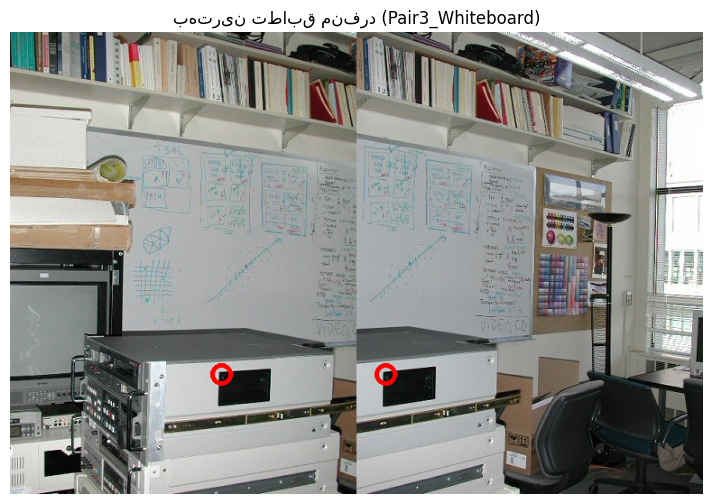

In [8]:
plt.figure(figsize=(10,6))
plt.imshow(cv2.imread(f'{OUT_DIR}/Part_2/Pair3_Whiteboard_best_match.png')[:,:,::-1])
plt.axis('off')
plt.title('بهترین تطابق منفرد (Pair3_Whiteboard)')
plt.show()


<div dir="rtl" style="text-align: right;">
 قسمت ۳ - تناظر نقاط کلیدی (mutual nearest neighbour)
</div>

In [ ]:
def mutual_matches(des1, des2, dist_thresh):
    D = cdist(des1, des2)   # فاصله اقلیدسی
    nn1 = np.argmin(D, axis=1)  
    nn2 = np.argmin(D, axis=0)   
    matches = []
    for i, j in enumerate(nn1):
        if nn2[j] == i and D[i,j] < dist_thresh:
            matches.append((i, j, D[i,j]))
    return matches


DIST_THRESH = 150

In [10]:
def draw_matches_sidebyside(im1, kp1, im2, kp2, matches):
    h1,w1 = im1.shape[:2]
    h2,w2 = im2.shape[:2]
    H = max(h1,h2)
    canvas = np.zeros((H, w1+w2, 3), dtype=np.uint8)
    canvas[:h1,:w1] = im1
    canvas[:h2, w1:w1+w2] = im2
    for i,j,d in matches:
        p1 = tuple(np.round(kp1[i].pt).astype(int))
        p2 = tuple(np.round(np.array(kp2[j].pt)+np.array([w1,0])).astype(int))
        cv2.circle(canvas, p1, 3, (255,0,0), 1)
        cv2.circle(canvas, p2, 3, (255,0,0), 1)
        cv2.line(canvas, p1, p2, (0,255,0), 1)
    return canvas

match_data = {}
for pair_name in pairs:
    kp1, des1 = sift_data[(pair_name,'im1')]
    kp2, des2 = sift_data[(pair_name,'im2')]
    matches = mutual_matches(des1, des2, DIST_THRESH)
    match_data[pair_name] = matches
    vis = draw_matches_sidebyside(data[pair_name]['im1'], kp1, data[pair_name]['im2'], kp2, matches)
    cv2.imwrite(f'{OUT_DIR}/Part_3/{pair_name}_matches.png', cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
    print(pair_name, 'n matches:', len(matches))

Pair1_Courtyard n matches: 420


Pair2_Cubicle n matches: 1508
Pair3_Whiteboard n matches: 104


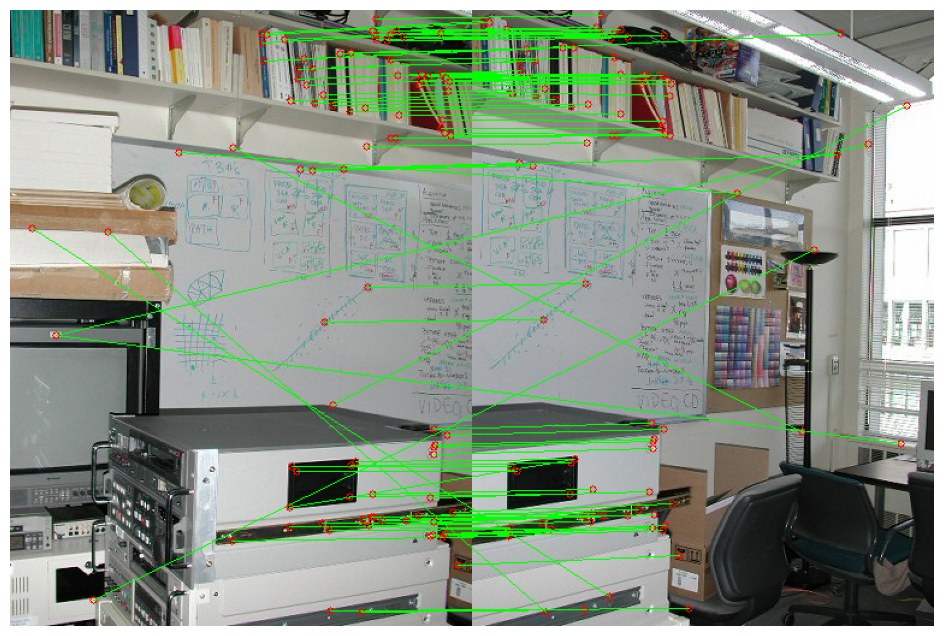

In [11]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.imread(f'{OUT_DIR}/Part_3/Pair3_Whiteboard_matches.png')[:,:,::-1])
plt.axis('off')
plt.show()

In [12]:
def estimate_error_rate(matches, kp1, kp2, w1, slope_tol=0.05):
    slopes = []
    for i,j,d in matches:
        p1 = kp1[i].pt
        p2 = kp2[j].pt
        dx = (p2[0]+w1) - p1[0]
        dy = p2[1] - p1[1]
        slopes.append(dy/dx)
    slopes = np.array(slopes)
    med = np.median(slopes)
    bad = np.sum(np.abs(slopes-med) > slope_tol)
    return 100*bad/len(matches), med

for pair_name in pairs:
    kp1,_ = sift_data[(pair_name,'im1')]
    kp2,_ = sift_data[(pair_name,'im2')]
    w1 = data[pair_name]['im1'].shape[1]
    err_pct, med_slope = estimate_error_rate(match_data[pair_name], kp1, kp2, w1)
    print(pair_name, 'error rate ~ %.1f%%'%err_pct, 'median slope', round(med_slope,4))

Pair1_Courtyard error rate ~ 1.4% median slope 0.0034
Pair2_Cubicle error rate ~ 11.5% median slope 0.0017
Pair3_Whiteboard error rate ~ 8.7% median slope -0.0157



<div dir="rtl" style="text-align: right;">
 قسمت ۴ - Homography و RANSAC
</div>

In [13]:
homo_data = {}
for pair_name in pairs:
    kp1,_ = sift_data[(pair_name,'im1')]
    kp2,_ = sift_data[(pair_name,'im2')]
    matches = match_data[pair_name]
    pts1 = np.float32([kp1[i].pt for i,j,d in matches])
    pts2 = np.float32([kp2[j].pt for i,j,d in matches])

    # Hmat مختصات تصویر۲ رو به مختصات تصویر۱ میبره (src=pts2, dst=pts1)
    Hmat, inlier_mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
    n_inliers = int(inlier_mask.sum())
    homo_data[pair_name] = Hmat
    print(pair_name, 'RANSAC inliers:', n_inliers, '/', len(matches), '(%.1f%%)'%(100*n_inliers/len(matches)))
    print(Hmat)

Pair1_Courtyard RANSAC inliers: 387 / 420 (92.1%)
[[ 1.28874076e+00 -1.10917007e-02 -3.63789795e+02]
 [ 2.01064352e-01  1.21107764e+00 -8.27463813e+01]
 [ 5.54634778e-04 -2.38664840e-05  1.00000000e+00]]
Pair2_Cubicle RANSAC inliers: 774 / 1508 (51.3%)
[[ 1.09054359e+00  2.38645694e-02 -2.99253022e+02]
 [ 3.80007760e-04  1.05905632e+00 -6.40686678e+00]
 [ 7.68009133e-05  3.67813151e-06  1.00000000e+00]]
Pair3_Whiteboard RANSAC inliers: 91 / 104 (87.5%)
[[ 8.70090781e-01  5.74043701e-03  2.01446336e+02]
 [-8.65606481e-02  9.68414829e-01  1.12845917e+01]
 [-3.35925372e-04  3.42213435e-06  1.00000000e+00]]


In [14]:
def warp_full(im1, im2, Hmat):
    h1,w1 = im1.shape[:2]
    h2,w2 = im2.shape[:2]
    corners2 = np.float32([[0,0],[w2,0],[w2,h2],[0,h2]]).reshape(-1,1,2)
    corners2_t = cv2.perspectiveTransform(corners2, Hmat)
    corners1 = np.float32([[0,0],[w1,0],[w1,h1],[0,h1]]).reshape(-1,1,2)
    all_corners = np.concatenate([corners1, corners2_t], axis=0)
    xmin, ymin = np.floor(all_corners.min(axis=0).ravel()).astype(int)
    xmax, ymax = np.ceil(all_corners.max(axis=0).ravel()).astype(int)
    translate = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]], dtype=np.float64)
    Hfinal = translate @ Hmat
    out_w, out_h = xmax-xmin, ymax-ymin
    warped2 = cv2.warpPerspective(im2, Hfinal, (out_w, out_h))
    canvas1 = np.zeros((out_h, out_w, 3), dtype=np.uint8)
    ox, oy = -xmin, -ymin
    canvas1[oy:oy+h1, ox:ox+w1] = im1
    return canvas1, warped2, (ox,oy)

warp_results = {}
for pair_name in pairs:
    im1 = data[pair_name]['im1']
    im2 = data[pair_name]['im2']
    canvas1, warped2, offset = warp_full(im1, im2, homo_data[pair_name])
    warp_results[pair_name] = (canvas1, warped2, offset)
    cv2.imwrite(f'{OUT_DIR}/Part_4/{pair_name}_view2_warped.png', cv2.cvtColor(warped2, cv2.COLOR_RGB2BGR))
    print(pair_name, 'canvas size', warped2.shape)

Pair1_Courtyard canvas size (977, 908, 3)


Pair2_Cubicle canvas size (913, 1452, 3)


Pair3_Whiteboard canvas size (569, 618, 3)


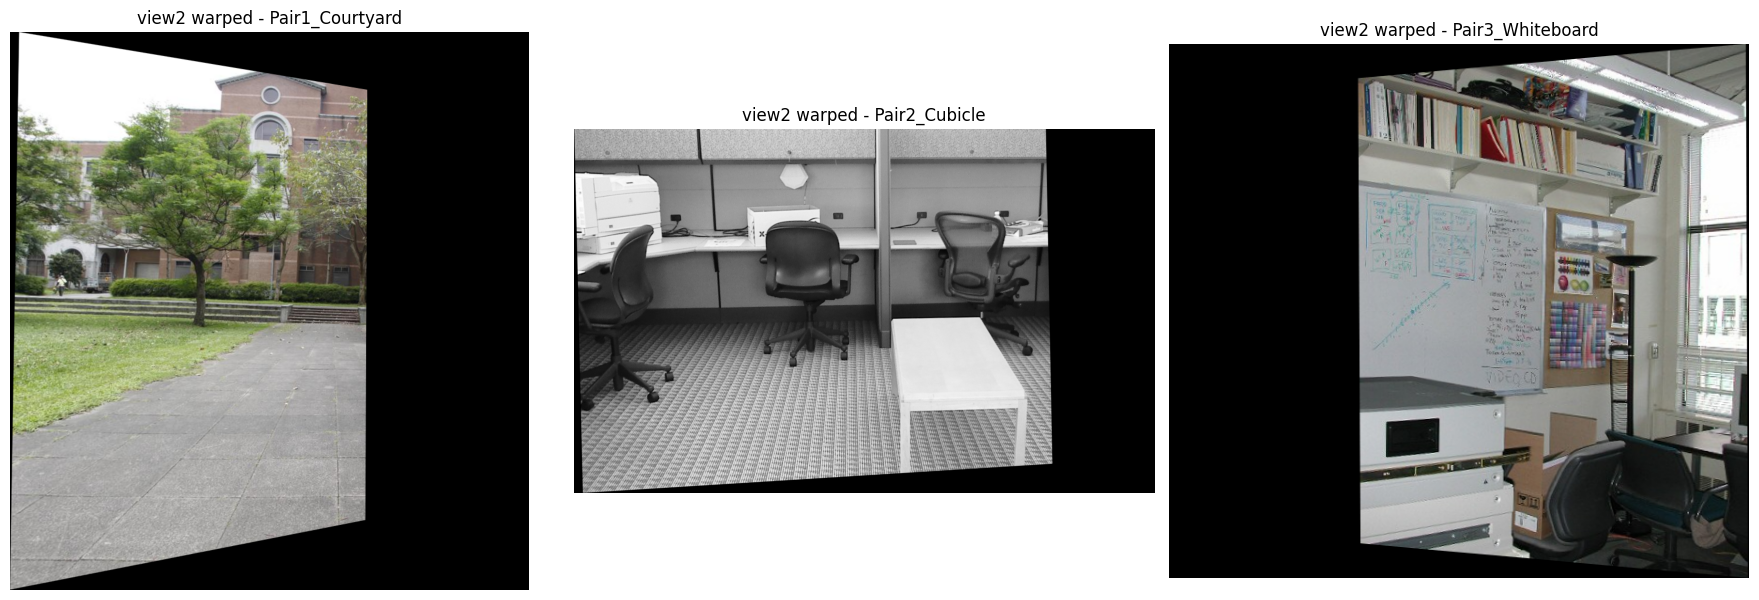

In [15]:
fig, axes = plt.subplots(1, len(pairs), figsize=(6*len(pairs), 6))
for ax, pair_name in zip(axes, pairs):
    ax.imshow(warp_results[pair_name][1])
    ax.set_title('view2 warped - '+pair_name)
    ax.axis('off')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۵ - Linear Blending
</div>

In [ ]:
def linear_blend(canvas1, warped2):
    out_h, out_w = canvas1.shape[:2]
    mask1 = canvas1.sum(axis=2) > 0
    mask2 = warped2.sum(axis=2) > 0
    overlap = mask1 & mask2

    alpha = np.zeros((out_h,out_w), dtype=np.float32)
    alpha[mask1] = 1.0
    ys, xs = np.where(overlap)
    if len(xs) > 0:
        xleft, xright = xs.min(), xs.max()
        for x in range(xleft, xright+1):
            w = 1 - (x-xleft)/(xright-xleft+1e-6)
            alpha[:,x] = np.where(overlap[:,x], w, alpha[:,x])

    alpha3 = alpha[:,:,None]
    blended = canvas1.astype(np.float32)*alpha3 + warped2.astype(np.float32)*(1-alpha3)
    only2 = mask2 & (~mask1)
    blended[only2] = warped2[only2]
    only1 = mask1 & (~mask2)
    blended[only1] = canvas1[only1]
    return np.clip(blended,0,255).astype(np.uint8)

final_pano = {}
for pair_name in pairs:
    canvas1, warped2, offset = warp_results[pair_name]
    pano = linear_blend(canvas1, warped2)
    final_pano[pair_name] = pano
    cv2.imwrite(f'{OUT_DIR}/Part_5/{pair_name}_panorama.png', cv2.cvtColor(pano, cv2.COLOR_RGB2BGR))

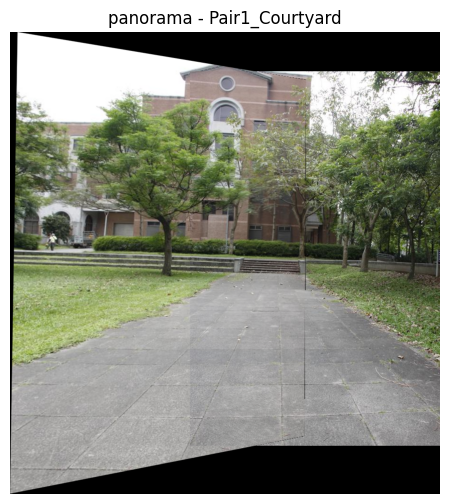

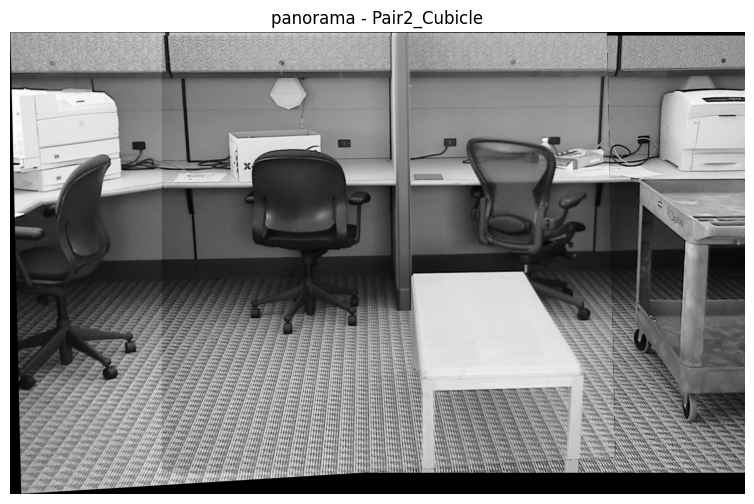

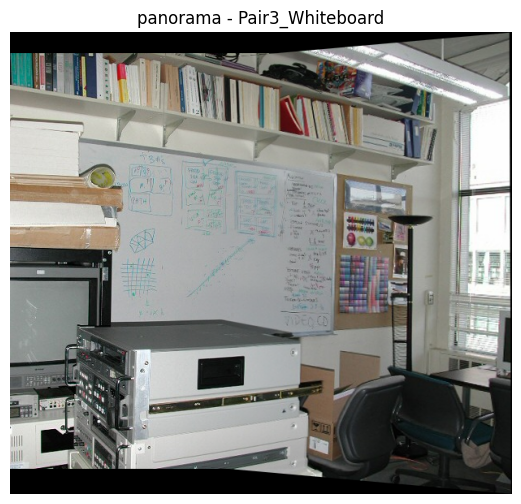

In [17]:
for pair_name in pairs:
    plt.figure(figsize=(12,6))
    plt.imshow(final_pano[pair_name])
    plt.axis('off')
    plt.title('panorama - '+pair_name)
    plt.show()